In [1]:
import pandas as pd
import numpy as np

In [9]:
data= pd.read_csv(r'nutrition.csv')
data.head()

,ID,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,...,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
0,1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,...,0.034,0.005,24.0,0.000,0.02,2.0,0.000,24.0,1.0,0.09
1,1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,...,0.034,0.005,24.0,0.016,0.16,2.0,0.004,23.0,1.0,0.05
2,1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,...,0.005,0.001,4.0,0.001,0.00,0.0,0.000,3.0,0.0,0.01
3,1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,...,0.382,0.029,528.0,0.040,0.31,23.0,0.009,387.0,14.5,2.66
4,1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,...,0.351,0.014,674.0,0.024,0.43,24.0,0.012,451.0,14.5,2.60


# 1
https://real-statistics.com/multivariate-statistics/factor-analysis/factor-analysis-example/

In [2]:
data= pd.read_csv(r'factor1.csv')
data.head()

,Expect,Entertain,Comm,Expert,Motivate,Caring,Charisma,Passion,Friendly
0,2,8,1,4,7,5,4,4,8
1,4,8,5,3,7,7,7,6,6
2,2,8,2,3,6,7,1,3,7
3,4,8,4,2,8,7,7,5,7
4,3,8,5,4,8,8,7,6,7


In [3]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from factor_analyzer import FactorAnalyzer

In [4]:
# Step 2: 因子分析
fa = FactorAnalyzer(rotation=None)  # 初始化因子分析，不进行旋转
fa.fit(data)

# 获取解释方差（Eigenvalues），用于碎石图
ev, v = fa.get_eigenvalues()

In [11]:
ev

array([2.88043691, 1.43865439, 1.16392965, 1.02445271, 0.70520866,
       0.64762341, 0.56239325, 0.3452484 , 0.23205262])

In [10]:
v

array([ 2.44750033,  1.1918652 ,  0.54934712,  0.25742003,  0.07280987,
        0.04413639, -0.03422256, -0.07593111, -0.26859622])

In [12]:
fa.get_eigenvalues()

(array([2.88043691, 1.43865439, 1.16392965, 1.02445271, 0.70520866,
        0.64762341, 0.56239325, 0.3452484 , 0.23205262]),
 array([ 2.59862777e+00,  1.10009901e+00,  9.23060832e-01,  5.98460106e-01,
         3.81239211e-01,  3.50758041e-02,  3.96194337e-04, -7.87876055e-03,
        -3.11547202e-02]))

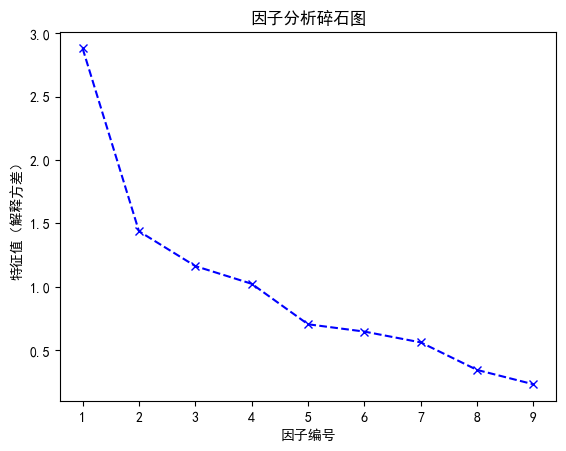

In [6]:
# Step 3: 绘制碎石图
plt.plot(range(1, len(ev) + 1), ev, 'bx--')
plt.xlabel('因子编号')
plt.ylabel('特征值（解释方差）')
plt.title('因子分析碎石图')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.show()

In [9]:
# Step 4: 如果确定因子数，重新进行因子分析并获取因子载荷矩阵
n_factors = 5  # 假设我们选择3个因子
fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
fa.fit(data)

# 因子载荷矩阵
factor_loadings = pd.DataFrame(fa.loadings_, columns=[f'因子{i+1}' for i in range(n_factors)], index=data.columns)
print("\n因子载荷矩阵：")
print(factor_loadings)

# 因子解释方差
factor_variance = fa.get_factor_variance()
print("\n因子解释方差：")
print(pd.DataFrame(factor_variance, index=['方差', '方差贡献率', '累计方差贡献率']))


因子载荷矩阵：
                因子1       因子2       因子3       因子4       因子5
Expect     0.035905  0.123875 -0.016785 -0.725849 -0.201572
Entertain  0.346860 -0.020511  0.900137  0.190835  0.173891
Comm       0.761199  0.030195  0.196468 -0.118383  0.162528
Expert     0.130382  0.983240  0.011275 -0.020639  0.109655
Motivate   0.260337  0.107551  0.054534  0.093817  0.527160
Caring     0.028409 -0.012962  0.018862  0.006468  0.508531
Charisma   0.929525  0.114187  0.107346  0.058585  0.144197
Passion    0.366525  0.164866  0.181038  0.097118  0.377988
Friendly   0.025918  0.205670  0.347694  0.538968 -0.132042

因子解释方差：
                0         1         2         3         4
方差       1.785635  1.077694  1.017774  0.889909  0.826913
方差贡献率    0.198404  0.119744  0.113086  0.098879  0.091879
累计方差贡献率  0.198404  0.318148  0.431234  0.530112  0.621992


# 2
https://statisticsbyjim.com/basics/factor-analysis/

In [13]:
data= pd.read_csv(r'FactorAnalysis.csv')

In [14]:
data.head()

,Academic record,Appearance,Communication,Company Fit,Experience,Job Fit,Letter,Likeability,Organization,Potential,Resume,Self-Confidence
0,6,8,7,5,6,5,7,7,7,6,7,7
1,9,8,8,8,10,9,8,9,8,9,9,9
2,6,7,7,6,6,7,7,8,8,6,6,8
3,7,8,6,5,8,5,9,8,7,8,7,7
4,4,7,8,6,6,6,6,7,8,5,4,6


In [15]:
# Step 2: 因子分析
fa = FactorAnalyzer(rotation=None)  # 初始化因子分析，不进行旋转
fa.fit(data)

# 获取解释方差（Eigenvalues），用于碎石图
ev, v = fa.get_eigenvalues()

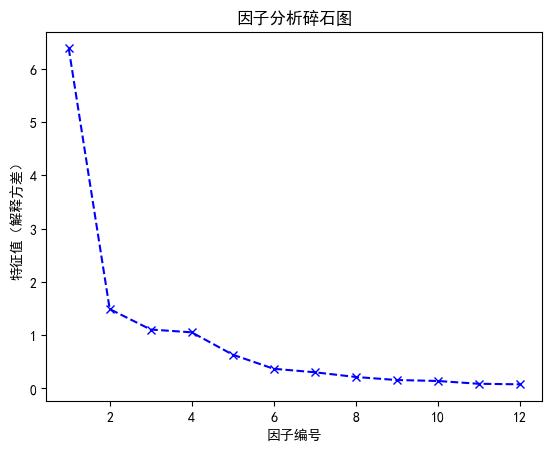

In [16]:
# Step 3: 绘制碎石图
plt.plot(range(1, len(ev) + 1), ev, 'bx--')
plt.xlabel('因子编号')
plt.ylabel('特征值（解释方差）')
plt.title('因子分析碎石图')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.show()

In [17]:
ev

array([6.3876438 , 1.48846472, 1.10447808, 1.05164512, 0.63250779,
       0.36695649, 0.30158363, 0.21291441, 0.15571561, 0.13792457,
       0.08512934, 0.07503646])

In [20]:
# Step 4: 如果确定因子数，重新进行因子分析并获取因子载荷矩阵
n_factors =4  # 假设我们选择3个因子
fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
fa.fit(data)

# 因子载荷矩阵
factor_loadings = pd.DataFrame(fa.loadings_, columns=[f'因子{i+1}' for i in range(n_factors)], index=data.columns)
print("\n因子载荷矩阵：")
print(factor_loadings)

# 因子解释方差
factor_variance = fa.get_factor_variance()
print("\n因子解释方差：")
print(pd.DataFrame(factor_variance, index=['方差', '方差贡献率', '累计方差贡献率']))


因子载荷矩阵：
                      因子1       因子2       因子3       因子4
Academic record  0.713126  0.177758  0.268828  0.154197
Appearance       0.230178  0.272117  0.704275  0.171338
Communication    0.117113  0.760158  0.309187  0.207765
Company Fit      0.521235  0.651528  0.151362  0.187478
Experience       0.732405 -0.032039  0.180466  0.327436
Job Fit          0.614176  0.531269  0.170007  0.206448
Letter           0.222720  0.243081  0.058946  0.904290
Likeability      0.226138  0.321319  0.688252  0.184864
Organization     0.092646  0.843501  0.359644  0.087206
Potential        0.854681  0.256622  0.284694  0.118462
Resume           0.286057  0.129288  0.330974  0.802476
Self-Confidence  0.272928  0.210040  0.815610  0.085430

因子解释方差：
                0         1         2         3
方差       2.756685  2.391764  2.210573  1.806103
方差贡献率    0.229724  0.199314  0.184214  0.150509
累计方差贡献率  0.229724  0.429037  0.613252  0.763760


# 3
https://www.kaggle.com/code/mathan/factor-analysis-on-match-statistics/notebook

In [59]:
data= pd.read_csv(r'FIFA 2018 Statistics.csv')
data.head()

,Date,Team,Opponent,Goal Scored,Ball Possession %,Attempts,On-Target,Off-Target,Blocked,Corners,...,Yellow Card,Yellow & Red,Red,Man of the Match,1st Goal,Round,PSO,Goals in PSO,Own goals,Own goal Time
0,14-06-2018,Russia,Saudi Arabia,5,40,13,7,3,3,6,...,0,0,0,Yes,12.0,Group Stage,No,0,NaN,NaN
1,14-06-2018,Saudi Arabia,Russia,0,60,6,0,3,3,2,...,0,0,0,No,NaN,Group Stage,No,0,NaN,NaN
2,15-06-2018,Egypt,Uruguay,0,43,8,3,3,2,0,...,2,0,0,No,NaN,Group Stage,No,0,NaN,NaN
3,15-06-2018,Uruguay,Egypt,1,57,14,4,6,4,5,...,0,0,0,Yes,89.0,Group Stage,No,0,NaN,NaN
4,15-06-2018,Morocco,Iran,0,64,13,3,6,4,5,...,1,0,0,No,NaN,Group Stage,No,0,1.0,90.0


In [27]:
data.columns

Index(['Date', 'Team', 'Opponent', 'Goal Scored', 'Ball Possession %',
       'Attempts', 'On-Target', 'Off-Target', 'Blocked', 'Corners', 'Offsides',
       'Free Kicks', 'Saves', 'Pass Accuracy %', 'Passes',
       'Distance Covered (Kms)', 'Fouls Committed', 'Yellow Card',
       'Yellow & Red', 'Red', 'Man of the Match', '1st Goal', 'Round', 'PSO',
       'Goals in PSO', 'Own goals', 'Own goal Time'],
      dtype='object')

In [60]:
data=data[["Goal Scored","Ball Possession %","Attempts","Corners","Free Kicks","Saves","Pass Accuracy %","Passes","Fouls Committed","Yellow Card","Red"]]

In [61]:
data.head()

,Goal Scored,Ball Possession %,Attempts,Corners,Free Kicks,Saves,Pass Accuracy %,Passes,Fouls Committed,Yellow Card,Red
0,5,40,13,6,11,0,78,306,22,0,0
1,0,60,6,2,25,2,86,511,10,0,0
2,0,43,8,0,7,3,78,395,12,2,0
3,1,57,14,5,13,3,86,589,6,0,0
4,0,64,13,5,14,2,86,433,22,1,0


In [62]:
# Step 1: 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)  # 将数据标准化
X_scaled_df = pd.DataFrame(X_scaled, columns=data.columns)  # 转换为DataFrame方便查看

In [63]:
# Step 2: 因子分析
fa = FactorAnalyzer(rotation=None)  # 初始化因子分析，不进行旋转
fa.fit(X_scaled_df)

# 获取解释方差（Eigenvalues），用于碎石图
ev, v = fa.get_eigenvalues()

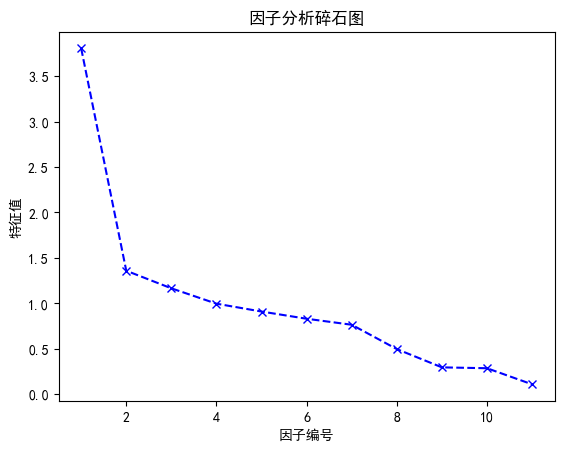

In [64]:
# Step 3: 绘制碎石图
plt.plot(range(1, len(ev) + 1), ev, 'bx--')
plt.xlabel('因子编号')
plt.ylabel('特征值')
plt.title('因子分析碎石图')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.show()

In [65]:
ev

array([3.80992662, 1.35780596, 1.1639536 , 0.99464713, 0.90785001,
       0.82848648, 0.76228781, 0.49390616, 0.2925618 , 0.2829044 ,
       0.10567003])

In [66]:
# Step 4: 如果确定因子数，重新进行因子分析并获取因子载荷矩阵
n_factors =4  # 假设我们选择3个因子
fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
fa.fit(data)

# 因子载荷矩阵
factor_loadings = pd.DataFrame(fa.loadings_, columns=[f'因子{i+1}' for i in range(n_factors)], index=data.columns)
print("\n因子载荷矩阵：")
print(factor_loadings)

# 因子解释方差
factor_variance = fa.get_factor_variance()
print("\n因子解释方差：")
print(pd.DataFrame(factor_variance, index=['方差', '方差贡献率', '累计方差贡献率']))


因子载荷矩阵：
                        因子1       因子2       因子3       因子4
Goal Scored        0.018452  0.061981 -0.011685  0.250327
Ball Possession %  0.896344  0.289471 -0.129117  0.167426
Attempts           0.353428  0.635058 -0.192254  0.221440
Corners            0.288803  0.896847 -0.096580 -0.012006
Free Kicks         0.183616  0.041201  0.090277  0.412659
Saves             -0.191163 -0.195955  0.024096 -0.362341
Pass Accuracy %    0.708476  0.127307 -0.180316  0.112026
Passes             0.840170  0.310021 -0.206261  0.106845
Fouls Committed   -0.200924 -0.013453  0.975400  0.063364
Yellow Card       -0.096615 -0.105763  0.421228 -0.041722
Red                0.035456  0.116440  0.046085 -0.256874

因子解释方差：
                0         1         2         3
方差       2.341135  1.472610  1.277847  0.537159
方差贡献率    0.212830  0.133874  0.116168  0.048833
累计方差贡献率  0.212830  0.346704  0.462872  0.511705


# 4


In [52]:
data= pd.read_csv(r'应聘数据.csv',encoding='gbk')
data.head()

,应聘者编号,简历格式,外观,学术能力,兴趣爱好,自信心,洞察力,诚信度,销售能力,工作经验,工作魄力,志向抱负,理解能力,潜能,求职渴望度,适应力
0,1,6,7,2,5,8,7,8,8,3,8,9,7,5,7,10
1,2,9,10,5,8,10,9,9,10,5,9,9,8,8,8,10
2,3,7,8,3,6,9,8,9,7,4,9,9,8,6,8,10
3,4,5,6,8,5,6,5,9,2,8,4,5,8,7,6,5
4,5,6,8,8,8,4,4,9,5,8,5,5,8,8,7,7


In [53]:
# Step 2: 因子分析
fa = FactorAnalyzer(rotation=None)  # 初始化因子分析，不进行旋转
fa.fit(data)

# 获取解释方差（Eigenvalues），用于碎石图
ev, v = fa.get_eigenvalues()

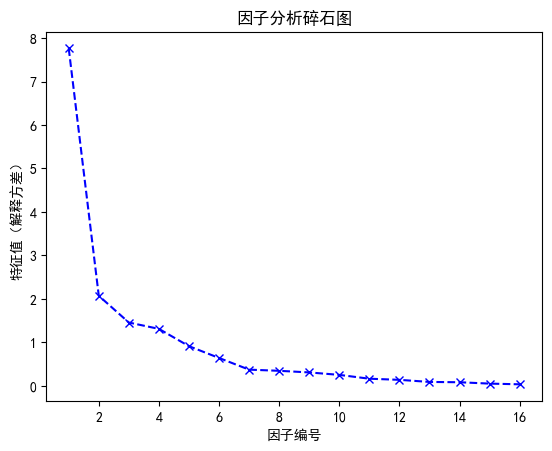

In [54]:
# Step 3: 绘制碎石图
plt.plot(range(1, len(ev) + 1), ev, 'bx--')
plt.xlabel('因子编号')
plt.ylabel('特征值（解释方差）')
plt.title('因子分析碎石图')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.show()

In [43]:
ev

array([7.76331118, 2.07200466, 1.45657481, 1.31065725, 0.91265216,
       0.64171228, 0.37274769, 0.346124  , 0.30898325, 0.25239633,
       0.16425591, 0.13844449, 0.09012519, 0.08294801, 0.05162302,
       0.03543977])

In [58]:
# Step 4: 如果确定因子数，重新进行因子分析并获取因子载荷矩阵
n_factors =4  # 假设我们选择3个因子
fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
fa.fit(data)

# 因子载荷矩阵
factor_loadings = pd.DataFrame(fa.loadings_, columns=[f'因子{i+1}' for i in range(n_factors)], index=data.columns)
print("\n因子载荷矩阵：")
print(factor_loadings)

# 因子解释方差
factor_variance = fa.get_factor_variance()
print("\n因子解释方差：")
print(pd.DataFrame(factor_variance, index=['方差', '方差贡献率', '累计方差贡献率']))


因子载荷矩阵：
            因子1       因子2       因子3       因子4
应聘者编号 -0.432795 -0.313959  0.005139  0.221159
简历格式   0.126838  0.678727  0.128828 -0.054148
外观     0.454472  0.180905  0.252980  0.065316
学术能力   0.070964  0.125792 -0.012091  0.864430
兴趣爱好   0.212609  0.232087  0.901964 -0.028524
自信心    0.907693 -0.100002  0.167743 -0.064153
洞察力    0.823054  0.103177  0.289615  0.040653
诚信度    0.259531 -0.209868  0.719474 -0.005848
销售能力   0.884490  0.237065  0.118314 -0.042603
工作经验   0.096006  0.798594 -0.056919  0.163016
工作魄力   0.765007  0.362806  0.175404 -0.046463
志向抱负   0.905245  0.174896  0.101674 -0.059869
理解能力   0.803517  0.269014  0.325512  0.137973
潜能     0.746741  0.342565  0.407355  0.228011
求职渴望度  0.427513  0.352978  0.550357 -0.477864
适应力    0.377081  0.806769  0.056018  0.037158

因子解释方差：
                0         1         2         3
方差       5.753327  2.547703  2.160235  1.144857
方差贡献率    0.359583  0.159231  0.135015  0.071554
累计方差贡献率  0.359583  0.518814  0.653829  0.725383


In [47]:
data= pd.read_csv(r'成绩.csv')
data.head()

,数学,物理,化学,语文,历史,英语
0,65,61,72,84,81,79
1,77,77,76,64,70,55
2,67,63,49,65,67,57
3,80,69,75,74,74,63
4,74,70,80,84,81,74


In [48]:
# Step 2: 因子分析
fa = FactorAnalyzer(rotation=None)  # 初始化因子分析，不进行旋转
fa.fit(data)

# 获取解释方差（Eigenvalues），用于碎石图
ev, v = fa.get_eigenvalues()

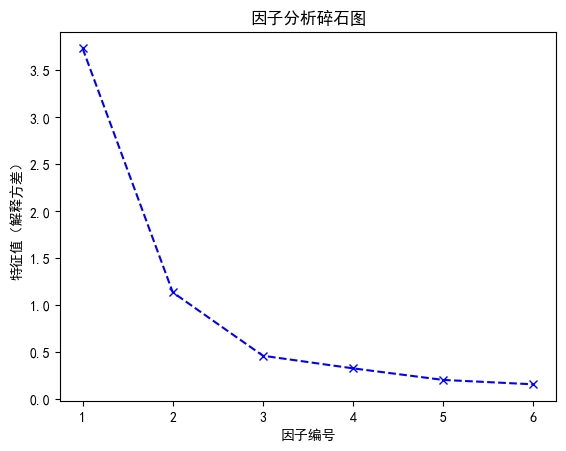

In [49]:
# Step 3: 绘制碎石图
plt.plot(range(1, len(ev) + 1), ev, 'bx--')
plt.xlabel('因子编号')
plt.ylabel('特征值（解释方差）')
plt.title('因子分析碎石图')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.show()

In [51]:
# Step 4: 如果确定因子数，重新进行因子分析并获取因子载荷矩阵
n_factors =2  # 假设我们选择3个因子
fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
fa.fit(data)

# 因子载荷矩阵
factor_loadings = pd.DataFrame(fa.loadings_, columns=[f'因子{i+1}' for i in range(n_factors)], index=data.columns)
print("\n因子载荷矩阵：")
print(factor_loadings)

# 因子解释方差
factor_variance = fa.get_factor_variance()
print("\n因子解释方差：")
print(pd.DataFrame(factor_variance, index=['方差', '方差贡献率', '累计方差贡献率']))


因子载荷矩阵：
         因子1       因子2
数学 -0.356983  0.785738
物理 -0.201099  0.718756
化学 -0.216153  0.692939
语文  0.851755 -0.371492
历史  0.854141 -0.235302
英语  0.870921 -0.243826

因子解释方差：
                0         1
方差       2.428147  1.866982
方差贡献率    0.404691  0.311164
累计方差贡献率  0.404691  0.715855


# 4
https://www.icourse163.org/learn/XMU-1206305809?tid=1454348451#/learn/content?type=detail&id=1227083123&cid=1242235142